In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "src").is_dir():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.models.logistic_regression import LogisticRegressionModel
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn import metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
)

In [10]:
RANDOM_STATE = 42

features = pd.read_csv("../data/features.txt", sep=r"\s+", header=None, names=["index", "feature_name"])

X_train = pd.read_csv("../data/train/X_train.txt", sep=r"\s+", header=None)
y_train = pd.read_csv("../data/train/y_train.txt", sep=r"\s+", header=None, names=["activity"])
subjects_train = pd.read_csv("../data/train/subject_train.txt", sep=r"\s+", header=None, names=["subject"])

X_test = pd.read_csv("../data/test/X_test.txt", sep=r"\s+", header=None)
y_test = pd.read_csv("../data/test/y_test.txt", sep=r"\s+", header=None, names=["activity"])
subjects_test = pd.read_csv("../data/test/subject_test.txt", sep=r"\s+", header=None, names=["subject"])

activity_labels = pd.read_csv("../data/activity_labels.txt", sep=r"\s+", header=None, names=["index", "activity_name"])

print("X_train:", X_train.shape, "| X_test:", X_test.shape)

X_train: (7352, 561) | X_test: (2947, 561)


In [11]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train["activity"].to_numpy())
y_test_enc = le.transform(y_test["activity"].to_numpy())
target_names = (
    activity_labels.set_index("index").loc[le.classes_, "activity_name"].astype(str).tolist()
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

In [12]:
model = LogisticRegressionModel(random_state=RANDOM_STATE)
model.fit(X_train_s, y_train_enc, 0.05)
pred = model.predict(X_test_s)
rows = []
rows.append(
            {
                "test_accuracy": accuracy_score(y_test_enc, pred),
                "test_macro_precision": precision_score(
                    y_test_enc, pred, average="macro", zero_division=0
                ),
                "test_macro_recall": recall_score(
                    y_test_enc, pred, average="macro", zero_division=0
                ),
                "test_macro_f1": f1_score(
                    y_test_enc, pred, average="macro", zero_division=0
                ),
            }
        )

,test_accuracy,test_macro_precision,test_macro_recall,test_macro_f1
0,0.947404,0.950939,0.946722,0.94785


                    precision    recall  f1-score   support

           WALKING      0.941     0.992     0.966       496
  WALKING_UPSTAIRS      0.957     0.941     0.949       471
WALKING_DOWNSTAIRS      0.985     0.948     0.966       420
           SITTING      0.955     0.868     0.909       491
          STANDING      0.868     0.962     0.913       532
            LAYING      1.000     0.970     0.985       537

          accuracy                          0.947      2947
         macro avg      0.951     0.947     0.948      2947
      weighted avg      0.950     0.947     0.948      2947



<Figure size 640x480 with 0 Axes>

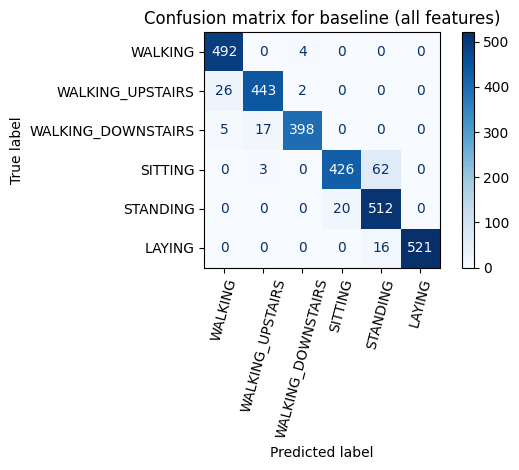

In [ ]:
results = pd.DataFrame(rows)
display(results)

print(classification_report(y_test_enc, pred, target_names=target_names, digits=3))

plt.figure()
c = confusion_matrix(y_test_enc, pred)
c_disp = metrics.ConfusionMatrixDisplay(confusion_matrix=c, display_labels=activity_labels["activity_name"].to_list())
c_disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion matrix for baseline (all features)")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()